In [ ]:
import pandas as pd

df = pd.read_csv("/outputs/analysis_same_culture.csv")

print("Overall results:")
print(df.describe())

print("\nAverage by culture:")
culture_summary = df.groupby("culture")[["precision","recall","f1"]].mean()

print(culture_summary)

culture_summary.to_csv("/outputs/culture_summary_same_culture.csv")

print("\nSaved culture summary to outputs/culture_summary_same_culture.csv")

Overall results:
       precision     recall         f1  events_original  events_llm
count  30.000000  30.000000  30.000000        30.000000   30.000000
mean    0.528280   0.503681   0.504827        95.266667   78.500000
std     0.155572   0.141188   0.122576        90.683585   43.463619
min     0.285714   0.205993   0.291005        15.000000   16.000000
25%     0.414373   0.395056   0.418094        48.250000   54.000000
50%     0.497748   0.490763   0.492761        72.000000   68.000000
75%     0.576002   0.616430   0.587773       112.750000  110.000000
max     0.973684   0.789474   0.728070       450.000000  219.000000

Average by culture:
                 precision    recall        f1
culture                                       
german            0.519659  0.575354  0.541644
native american   0.522547  0.478732  0.496815
persian           0.542635  0.456957  0.476023

Saved culture summary to outputs/culture_summary_same_culture.csv


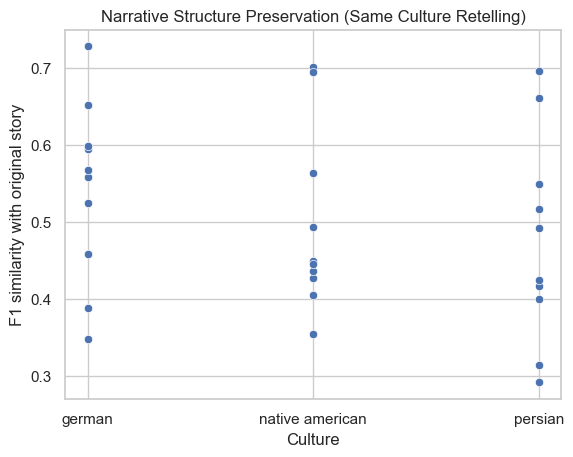

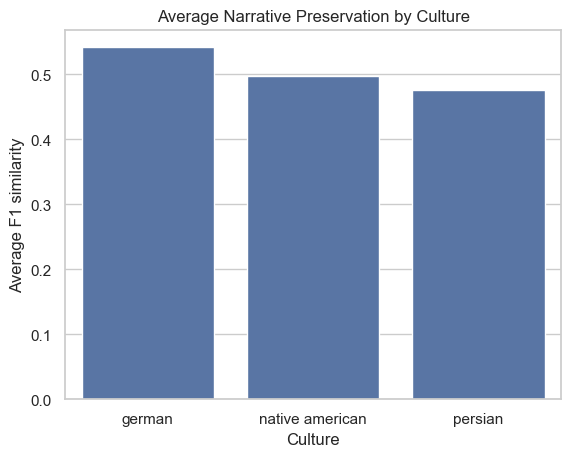

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outputs/analysis_same_culture.csv")

sns.set(style="whitegrid")

# -----------------------------
# Plot 1: F1 per story
# -----------------------------

plt.figure()

sns.scatterplot(
    data=df,
    x="culture",
    y="f1"
)

plt.title("Narrative Structure Preservation (Same Culture Retelling)")
plt.ylabel("F1 similarity with original story")
plt.xlabel("Culture")

plt.savefig("outputs/plot_f1_per_story.png", dpi=300)

plt.show()

# -----------------------------
# Plot 2: Average F1 per culture
# -----------------------------

culture_avg = df.groupby("culture")["f1"].mean().reset_index()

plt.figure()

sns.barplot(
    data=culture_avg,
    x="culture",
    y="f1"
)

plt.title("Average Narrative Preservation by Culture")
plt.ylabel("Average F1 similarity")
plt.xlabel("Culture")

plt.savefig("outputs/plot_f1_by_culture.png", dpi=300)

plt.show()

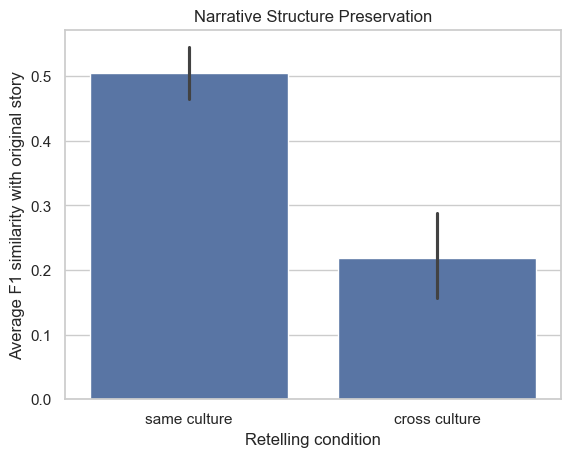

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

same["condition"] = "same culture"
cross["condition"] = "cross culture"

df = pd.concat([same, cross])

sns.set(style="whitegrid")

plt.figure()

sns.barplot(
    data=df,
    x="condition",
    y="f1"
)

plt.title("Narrative Structure Preservation")
plt.ylabel("Average F1 similarity with original story")
plt.xlabel("Retelling condition")

plt.savefig("outputs/plot_condition_comparison.png", dpi=300)

plt.show()

In [2]:
import pandas as pd

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

same["condition"] = "same_culture"
cross["condition"] = "cross_culture"

df = pd.concat([same, cross])

culture_summary = (
    df.groupby(["culture","condition"])["f1"]
    .mean()
    .reset_index()
)

print(culture_summary)

culture_summary.to_csv(
    "outputs/culture_condition_summary.csv",
    index=False
)

print("\nSaved summary to outputs/culture_condition_summary.csv")

           culture      condition        f1
0           german  cross_culture  0.301527
1           german   same_culture  0.541644
2  native american  cross_culture  0.087309
3  native american   same_culture  0.496815
4          persian  cross_culture  0.264671
5          persian   same_culture  0.476023

Saved summary to outputs/culture_condition_summary.csv


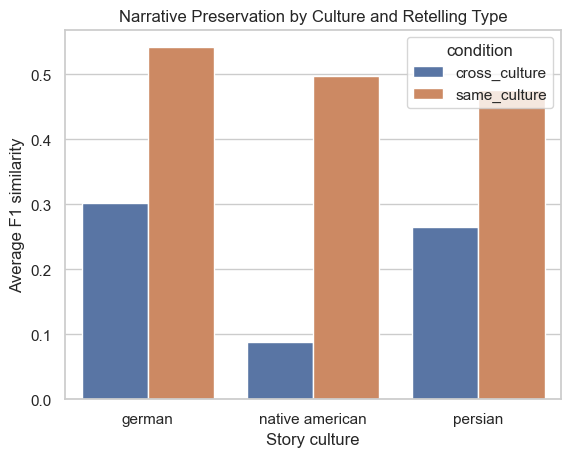

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure()

sns.barplot(
    data=culture_summary,
    x="culture",
    y="f1",
    hue="condition"
)

plt.title("Narrative Preservation by Culture and Retelling Type")
plt.ylabel("Average F1 similarity")
plt.xlabel("Story culture")

plt.savefig(
    "outputs/plot_culture_condition.png",
    dpi=300
)

plt.show()

In [4]:
pivot = culture_summary.pivot(
    index="culture",
    columns="condition",
    values="f1"
)

pivot["drop"] = pivot["same_culture"] - pivot["cross_culture"]

print(pivot)

condition        cross_culture  same_culture      drop
culture                                               
german                0.301527      0.541644  0.240117
native american       0.087309      0.496815  0.409506
persian               0.264671      0.476023  0.211353


In [5]:
import pandas as pd

same = pd.read_csv("outputs/analysis_same_culture.csv")
cross = pd.read_csv("outputs/analysis_cross_culture.csv")

print("Same-culture extremes:")
best_same = same.loc[same["f1"].idxmax()]
worst_same = same.loc[same["f1"].idxmin()]
print("\nHighest F1:")
print(best_same)
print("\nLowest F1:")
print(worst_same)

print("\nCross-culture extremes:")
best_cross = cross.loc[cross["f1"].idxmax()]
worst_cross = cross.loc[cross["f1"].idxmin()]
print("\nHighest F1:")
print(best_cross)
print("\nLowest F1:")
print(worst_cross)

Same-culture extremes:

Highest F1:
story_id                g07
culture              german
precision          0.747748
recall             0.709402
f1                  0.72807
events_original         117
events_llm              111
Name: 6, dtype: object

Lowest F1:
story_id                p10
culture             persian
precision          0.495495
recall             0.205993
f1                 0.291005
events_original         267
events_llm              111
Name: 29, dtype: object

Cross-culture extremes:

Highest F1:
story_id                g07
culture              german
precision          0.986486
recall             0.623932
f1                 0.764398
events_original         117
events_llm               74
Name: 6, dtype: object

Lowest F1:
story_id                       n01
culture            native american
precision                      0.0
recall                         0.0
f1                             0.0
events_original                 20
events_llm                      15

In [6]:
from pathlib import Path

def show_story_pair(story_id, condition="same"):
    
    human_path = Path(f"data/human") 
    llm_path = Path(f"data/llm/{'same_culture' if condition=='same' else 'cross_culture'}/{story_id}.txt")

    # find correct culture folder automatically
    import pandas as pd
    meta = pd.read_csv("data/metadata.csv")
    culture = meta[meta.story_id == story_id]["culture"].values[0]

    human_file = Path(f"data/human/{culture}/{story_id}.txt")

    print("\nORIGINAL STORY\n")
    print(human_file.read_text()[:2000])

    print("\n\nRETOLD STORY\n")
    print(llm_path.read_text()[:2000])

In [7]:
show_story_pair("g07", "same")
show_story_pair("n01", "cross")


ORIGINAL STORY

THE FISHERMAN AND HIS WIFE

There was once a fisherman who lived with his wife in a pigsty, close by the seaside. The fisherman used to go out all day long a-fishing; and one day, as he sat on the shore with his rod, looking at the sparkling waves and watching his line, all on a sudden his float was dragged away deep into the water: and in drawing it up he pulled out a great fish. But the fish said, â€کPray let me live! I am not a real fish; I am an enchanted prince: put me in the water again, and let me go!â€™ â€کOh, ho!â€™ said the man, â€کyou need not make so many words about the matter; I will have nothing to do with a fish that can talk: so swim away, sir, as soon as you please!â€™ Then he put him back into the water, and the fish darted straight down to the bottom, and left a long streak of blood behind him on the wave.

When the fisherman went home to his wife in the pigsty, he told her how he had caught a great fish, and how it had told him it was an enchanted 

In [8]:
import pandas as pd

df = pd.read_csv("outputs/graph_metrics_comparison.csv")

summary = df.groupby(["culture", "condition"])[[
    "compression_ratio_nodes",
    "compression_ratio_edges",
    "density_diff",
    "avg_degree_diff",
    "longest_path_diff"
]].mean()

print(summary)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/graph_metrics_comparison.csv'